# Lumora
## AI Radiology Assistant for Lung Disease (Pneumonia) Detection
> Dataset Url: https://www.kaggle.com/datasets/fatemehmehrparvar/lung-disease

In [32]:
from pathlib import Path
from PIL import Image
import numpy as np
from sklearn.model_selection import train_test_split
from collections import Counter
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix, ConfusionMatrixDisplay
from torch.nn import functional as F
import json

### 1. Image Preprocessing
Before training, the raw chest X-ray images undergo standardizing steps to ensure consistency:
*   **Resizing:** All images are resized to a uniform dimension of **224 x 224 x 3**.
*   **Normalization:** Pixel values are scaled to a ** range** to improve training stability.
*   **Data Splitting:** The dataset is **stratified**—ensuring all three classes (Normal, Viral Pneumonia, and Lung Opacity) are represented—and then split into training and testing sets.

In [2]:
input_dir = Path("data/Lung")
output_dir = Path("data/Lung_224")
output_dir.mkdir(parents=True, exist_ok=True)

target_size = (224, 224)
image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

for img_path in input_dir.rglob("*"):
    if img_path.suffix.lower() in image_exts:
        rel_path = img_path.relative_to(input_dir)
        save_path = output_dir / rel_path
        save_path.parent.mkdir(parents=True, exist_ok=True)

        with Image.open(img_path) as img:
            img = img.convert("RGB").resize(target_size, Image.Resampling.LANCZOS)
            img.save(save_path)

print(f"Resized images saved to: {output_dir}")

Resized images saved to: data/Lung_224


In [3]:
def load_and_normalize_image(image_path):
    with Image.open(image_path) as im:
        im = im.convert("RGB").resize(target_size, Image.Resampling.LANCZOS)
        return np.asarray(im, dtype=np.float32) / 255.0

normalized_img = load_and_normalize_image(save_path)
print(normalized_img.shape, normalized_img.min(), normalized_img.max())

(224, 224, 3) 0.0 1.0


In [4]:
image_paths = [p for p in output_dir.rglob("*") if p.suffix.lower() in image_exts]
labels = [p.parent.name for p in image_paths]

class_names = sorted(set(labels))

if len(class_names) != 3:
    raise ValueError(f"Expected 3 classes, found {len(class_names)}: {class_names}")

train_paths, test_paths, train_labels, test_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels,
)

print("Train class distribution:", Counter(train_labels))
print("Test class distribution:", Counter(test_labels))
print("Classes:", class_names)

Train class distribution: Counter({'Normal': 1000, 'Lung_Opacity': 900, 'Viral Pneumonia': 880})
Test class distribution: Counter({'Normal': 250, 'Lung_Opacity': 225, 'Viral Pneumonia': 220})
Classes: ['Lung_Opacity', 'Normal', 'Viral Pneumonia']


### 2. Spatial Feature Extraction (CNN)
The model uses a **ResNet50 architecture** to identify important spatial patterns in the images, such as lung limits, textures, and opacities.
*   **Residual Learning:** The ResNet structure utilizes residual mapping ($H(x)=F(x)+x$) to improve learning efficiency.
*   **Global Average Pooling (GAP):** After the convolutional layers, a GAP layer converts the complex feature maps into a more manageable **feature vector**.

In [8]:
# Dataset to load images from path lists (uses existing train_paths/test_paths and labels)
class ImagePathDataset(Dataset):
    def __init__(self, paths, labels, class_names, target_size):
        self.paths = paths
        self.labels = labels
        self.class_to_idx = {c: i for i, c in enumerate(class_names)}
        self.transform = transforms.Compose([
            transforms.Resize(target_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        p = self.paths[idx]
        img = Image.open(p).convert("RGB")
        x = self.transform(img)
        y = self.class_to_idx[self.labels[idx]]
        return x, y

# Build feature extractor based on pretrained ResNet50 (outputs 2048-d feature vector)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet50 = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
resnet50.fc = torch.nn.Identity()  # keep avgpool + flatten, return feature vector
resnet50 = resnet50.to(device)
resnet50.eval()

# Create datasets and loaders
train_dataset = ImagePathDataset(train_paths, train_labels, class_names, target_size)
test_dataset  = ImagePathDataset(test_paths,  test_labels,  class_names, target_size)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=0, pin_memory=False)
# For windows:
# train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
# test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

# Function to extract features for a loader
def extract_features(model, loader, device):
    feats_list = []
    labels_list = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            f = model(xb)  # (B, 2048)
            feats_list.append(f.cpu())
            labels_list.append(yb)
    features = torch.cat(feats_list, dim=0).numpy()
    labels = torch.cat(labels_list, dim=0).numpy()
    return features, labels

train_features, train_label_idxs = extract_features(resnet50, train_loader, device)
test_features,  test_label_idxs  = extract_features(resnet50, test_loader, device)

print("Train features:", train_features.shape, "Test features:", test_features.shape)

Train features: (2780, 2048) Test features: (695, 2048)


In [9]:
# Demonstrate Global Average Pooling (GAP) on one chest X-ray image

# Use the already loaded sample image path if available
sample_path = save_path if "save_path" in globals() else image_paths[0]

with Image.open(sample_path) as im:
	im = im.convert("RGB")

x = transforms.Compose([
	transforms.Resize(target_size),
	transforms.ToTensor(),
	transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])(im).unsqueeze(0).to(device)

# Feature maps before GAP: (1, 2048, H, W)
backbone = torch.nn.Sequential(*list(resnet50.children())[:-2]).to(device)
with torch.no_grad():
	feature_maps = backbone(x)
	gap_vector = torch.nn.functional.adaptive_avg_pool2d(feature_maps, (1, 1))
	gap_vector = torch.flatten(gap_vector, 1)

print("Feature maps shape:", feature_maps.shape)
print("After GAP shape:", gap_vector.shape)

Feature maps shape: torch.Size([1, 2048, 7, 7])
After GAP shape: torch.Size([1, 2048])


### 3. Sequential Feature Learning (LSTM)
The spatial features extracted by the CNN are reshaped and passed to a **Long Short-Term Memory (LSTM)** layer:
*   **Dependency Modeling:** An LSTM layer with **128 units** is used to identify deeper relationships and dependencies between the spatial features provided by the CNN.
*   **Fine Pattern Detection:** This hybrid step helps the model distinguish between very similar visual patterns, such as those found in viral pneumonia versus lung opacity.

In [10]:
# Reshape GAP feature vectors (2048) into sequences for LSTM input
seq_len = 32
feature_dim = train_features.shape[1]
if feature_dim % seq_len != 0:
	raise ValueError(f"Feature size {feature_dim} is not divisible by seq_len={seq_len}")

input_size = feature_dim // seq_len  # 2048 -> (32, 64)

X_train_seq = torch.tensor(train_features, dtype=torch.float32).view(-1, seq_len, input_size).to(device)
X_test_seq  = torch.tensor(test_features, dtype=torch.float32).view(-1, seq_len, input_size).to(device)

y_train = torch.tensor(train_label_idxs, dtype=torch.long).to(device)
y_test  = torch.tensor(test_label_idxs, dtype=torch.long).to(device)

# LSTM block for sequential feature learning (128 units)
class LSTMFeatureExtractor(torch.nn.Module):
	def __init__(self, input_size, hidden_size=128):
		super().__init__()
		self.lstm = torch.nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True)

	def forward(self, x):
		_, (h_n, _) = self.lstm(x)
		return h_n[-1]  # (batch, 128)

lstm_extractor = LSTMFeatureExtractor(input_size=input_size, hidden_size=128).to(device)

with torch.no_grad():
	train_lstm_features = lstm_extractor(X_train_seq)
	test_lstm_features = lstm_extractor(X_test_seq)

print("LSTM input shape (train):", X_train_seq.shape)
print("LSTM output shape (train):", train_lstm_features.shape)
print("LSTM input shape (test):", X_test_seq.shape)
print("LSTM output shape (test):", test_lstm_features.shape)

LSTM input shape (train): torch.Size([2780, 32, 64])
LSTM output shape (train): torch.Size([2780, 128])
LSTM input shape (test): torch.Size([695, 32, 64])
LSTM output shape (test): torch.Size([695, 128])


In [17]:
# LSTM + Dense(ReLU) + Dropout + Softmax(logits) classifier
class HybridLSTMClassifier(torch.nn.Module):
    def __init__(self, input_size, hidden_size=128, dense_size=128, num_classes=3, dropout=0.5):
        super().__init__()
        self.lstm = torch.nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        self.fc1 = torch.nn.Linear(hidden_size, dense_size)
        self.relu = torch.nn.ReLU()
        self.drop = torch.nn.Dropout(dropout)
        self.fc_out = torch.nn.Linear(dense_size, num_classes)

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        h = h_n[-1]
        z = self.drop(self.relu(self.fc1(h)))
        return self.fc_out(z)  # logits

model = HybridLSTMClassifier(
    input_size=input_size,
    hidden_size=128,
    dense_size=128,
    num_classes=len(class_names),
    dropout=0.5
).to(device)

train_ds = torch.utils.data.TensorDataset(X_train_seq, y_train)
test_ds = torch.utils.data.TensorDataset(X_test_seq, y_test)

train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
test_dl = DataLoader(test_ds, batch_size=128, shuffle=False)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

epochs = 50
train_losses = []
train_accs = []
for epoch in range(1, epochs + 1):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for xb, yb in train_dl:
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == yb).sum().item()
        total += yb.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d}/{epochs} | loss={train_loss:.4f} | acc={train_acc:.4f}")

# Evaluation
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_dl:
        logits = model(xb)
        preds = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_true.extend(yb.cpu().numpy())

acc = accuracy_score(all_true, all_preds)
prec, rec, f1, _ = precision_recall_fscore_support(all_true, all_preds, average="weighted", zero_division=0)

print(f"\nTest Accuracy : {acc:.4f}")
print(f"Test Precision: {prec:.4f}")
print(f"Test Recall   : {rec:.4f}")
print(f"Test F1-score : {f1:.4f}")
print("\nClassification Report:\n")
print(classification_report(all_true, all_preds, target_names=class_names, zero_division=0))

Epoch 01/50 | loss=0.9697 | acc=0.5194
Epoch 10/50 | loss=0.2823 | acc=0.8910
Epoch 20/50 | loss=0.2361 | acc=0.9162
Epoch 30/50 | loss=0.1915 | acc=0.9263
Epoch 40/50 | loss=0.1492 | acc=0.9460
Epoch 50/50 | loss=0.1163 | acc=0.9583

Test Accuracy : 0.8849
Test Precision: 0.8891
Test Recall   : 0.8849
Test F1-score : 0.8853

Classification Report:

                 precision    recall  f1-score   support

   Lung_Opacity       0.88      0.80      0.84       225
         Normal       0.81      0.90      0.85       250
Viral Pneumonia       0.99      0.96      0.97       220

       accuracy                           0.88       695
      macro avg       0.89      0.88      0.89       695
   weighted avg       0.89      0.88      0.89       695



### 4. Classification and Overfitting Prevention
The final part of the training architecture focuses on making a prediction while ensuring the model generalizes well:
*   **Hidden Layer:** A fully connected layer with **ReLU activation** processes the output from the LSTM.
*   **Dropout:** A **Dropout layer (0.5)** is applied, which randomly ignores half of the neurons during training to **prevent overfitting**.
*   **Softmax Output:** A final Softmax layer calculates the probability for each of the three disease classes and selects the one with the highest likelihood.

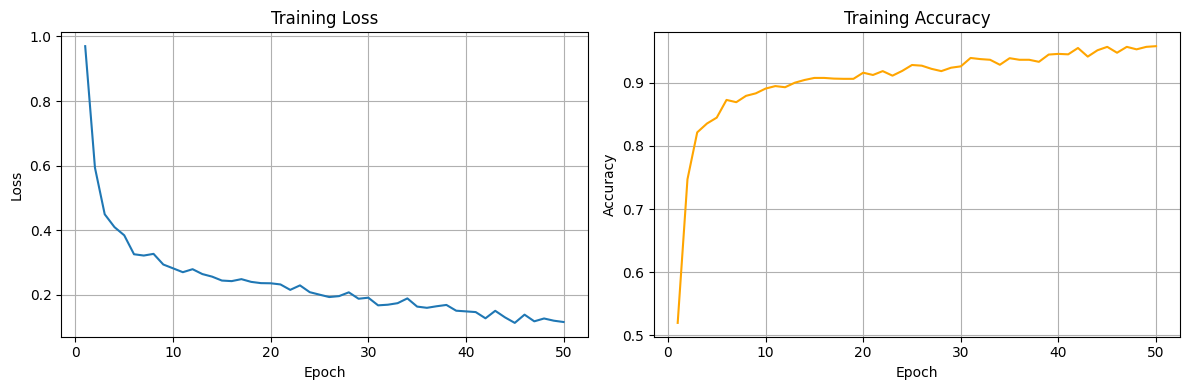

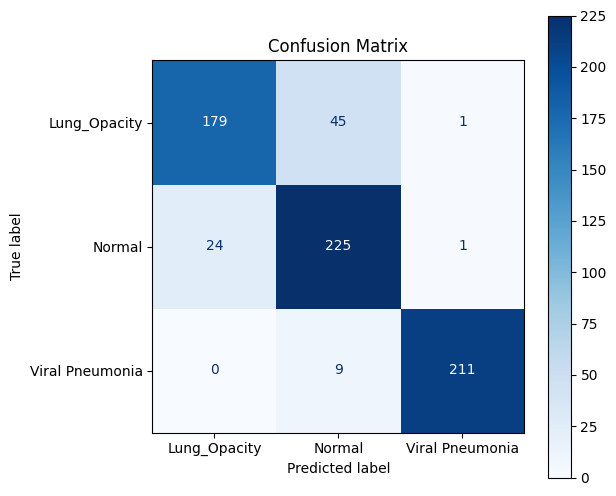

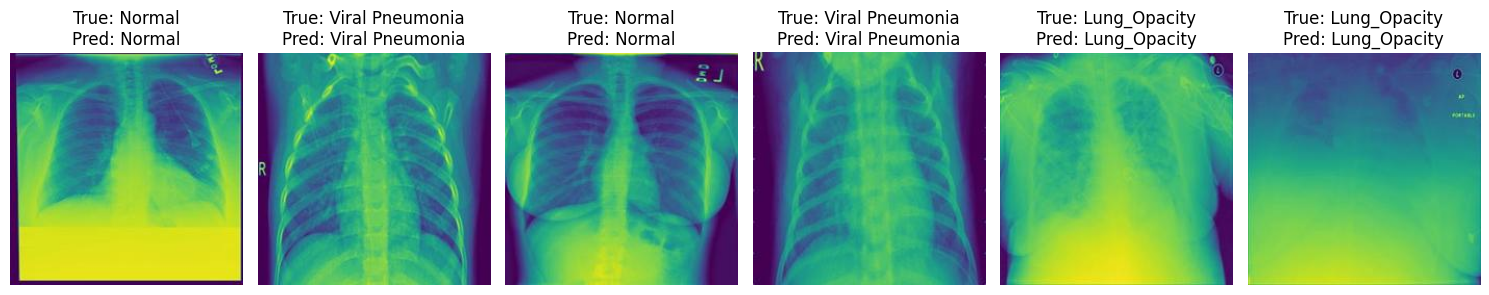

In [19]:
# Plot training loss and accuracy
epochs = list(range(1, len(train_losses) + 1))
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="train_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accs, label="train_acc", color="orange")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.grid(True)
plt.tight_layout()
plt.show()

# Evaluate on test set and compute confusion matrix
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_dl:
        xb = xb.to(device)
        logits = model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(yb.cpu().numpy())

cm = confusion_matrix(all_true, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

# Visualize a few test samples with predictions
n = min(6, len(test_paths))
fig, axs = plt.subplots(1, n, figsize=(15, 3))
for i in range(n):
    img = Image.open(test_paths[i]).convert("RGB").resize(target_size)
    axs[i].imshow(img)
    axs[i].axis("off")
    axs[i].set_title(f"True: {test_labels[i]}\nPred: {class_names[all_preds[i]]}")
plt.tight_layout()
plt.show()

In [20]:
# Demonstrate the effect of Dropout(0.5) on learned features

model.train()
sample_features = train_lstm_features[:5]

with torch.no_grad():
    dropped = model.drop(sample_features)

zero_fraction = (dropped == 0).float().mean().item()

print(f"Dropout probability: {model.drop.p}")
print(f"Fraction of zeroed activations in this sample: {zero_fraction:.2f}")
print("Original feature shape:", sample_features.shape)
print("After dropout shape:", dropped.shape)

Dropout probability: 0.5
Fraction of zeroed activations in this sample: 0.50
Original feature shape: torch.Size([5, 128])
After dropout shape: torch.Size([5, 128])


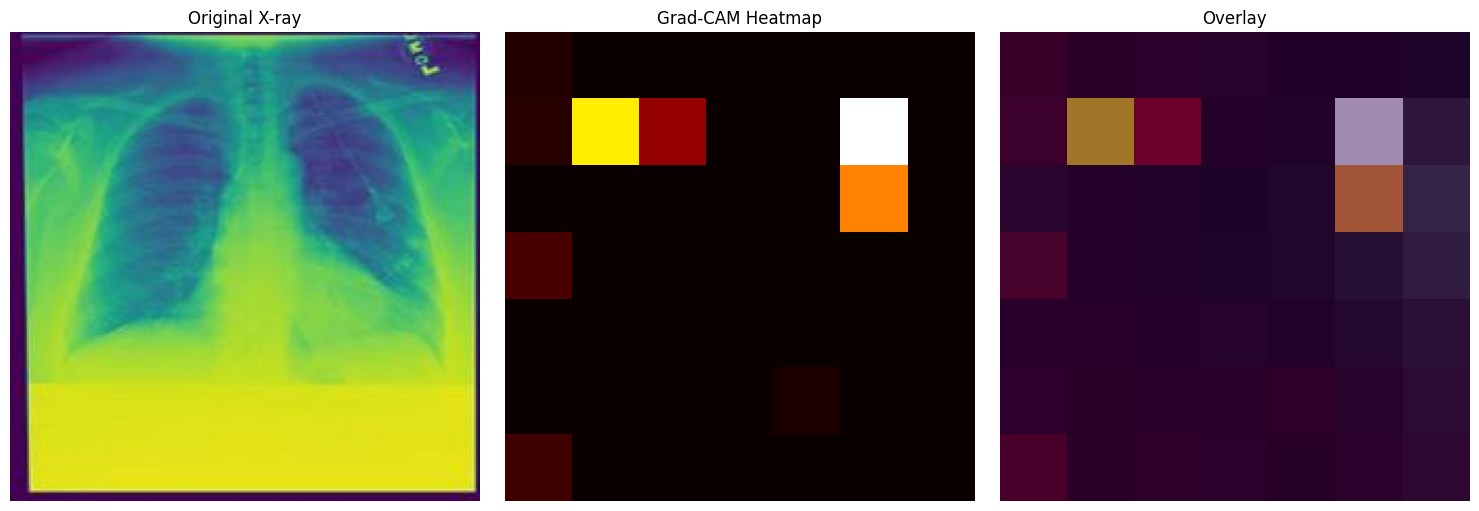

In [27]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self.save_activations)
        target_layer.register_full_backward_hook(self.save_gradients)

    def save_activations(self, module, input, output):
        self.activations = output

    def save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, x, class_idx):
        self.model.eval()

        output = self.model(x)  # (1, num_classes)

        self.model.zero_grad()
        score = output[0, class_idx]
        score.backward()

        weights = self.gradients[0].mean(dim=(1, 2))                         # (C,)
        cam = (weights.view(-1, 1, 1) * self.activations[0]).sum(dim=0)      # (H, W)
        cam = F.relu(cam)
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam.detach().cpu().numpy()


# Build full ResNet50 with classification head
num_classes = len(class_names)

grad_cam_model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
grad_cam_model.fc = torch.nn.Linear(2048, num_classes)
grad_cam_model = grad_cam_model.to(device)
grad_cam_model.eval()

# Target the last conv block
target_layer = grad_cam_model.layer4[-1]
grad_cam = GradCAM(grad_cam_model, target_layer)

# Prepare sample image
test_img = Image.open(test_paths[0]).convert("RGB").resize(target_size)
x_sample = transforms.Compose([
    transforms.Resize(target_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])(test_img).unsqueeze(0).to(device)

# Generate CAM
cam = grad_cam.generate(x_sample, class_idx=0)

# Visualize
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].imshow(test_img)
axs[0].set_title("Original X-ray")
axs[0].axis("off")

axs[1].imshow(cam, cmap="hot")
axs[1].set_title("Grad-CAM Heatmap")
axs[1].axis("off")

axs[2].imshow(test_img)
axs[2].imshow(cam, cmap="hot", alpha=0.5)
axs[2].set_title("Overlay")
axs[2].axis("off")

plt.tight_layout()
plt.show()

### 5. Model Evaluation and Visualization
Once trained, the model is assessed and interpreted using several tools:
*   **Performance Metrics:** The model is evaluated based on accuracy, precision, recall, and F1-score, achieving an overall **accuracy of 88%**.
*   **Training Analysis:** The authors analyze **accuracy and loss curves** for both training and validation to ensure the model learned effectively without fitting too closely to the training data.
*   **Grad-CAM:** To make the model "transparent," the researchers use **Grad-CAM** to generate heatmaps that highlight the specific lung regions the AI focused on when making its prediction.

In [28]:
# Evaluate trained model on test_dl and print metrics
model.eval()
preds, trues = [], []
with torch.no_grad():
    for xb, yb in test_dl:
        xb = xb.to(device)
        logits = model(xb)
        preds.extend(logits.argmax(dim=1).cpu().numpy())
        trues.extend(yb.cpu().numpy())

acc = accuracy_score(trues, preds)
prec, rec, f1, _ = precision_recall_fscore_support(trues, preds, average="weighted", zero_division=0)

print(f"Test Accuracy : {acc:.4f}")
print(f"Test Precision: {prec:.4f}")
print(f"Test Recall   : {rec:.4f}")
print(f"Test F1-score : {f1:.4f}")
print("\nClassification Report:\n", classification_report(trues, preds, target_names=class_names, zero_division=0))

Test Accuracy : 0.8849
Test Precision: 0.8891
Test Recall   : 0.8849
Test F1-score : 0.8853

Classification Report:
                  precision    recall  f1-score   support

   Lung_Opacity       0.88      0.80      0.84       225
         Normal       0.81      0.90      0.85       250
Viral Pneumonia       0.99      0.96      0.97       220

       accuracy                           0.88       695
      macro avg       0.89      0.88      0.89       695
   weighted avg       0.89      0.88      0.89       695



In [29]:
# Create a comprehensive summary report
summary_report = {
    "Model Architecture": {
        "Feature Extractor": "ResNet50 (pretrained)",
        "Feature Dimension": 2048,
        "LSTM Configuration": {
            "Input Sequence Length": seq_len,
            "Input Size per Step": 2048 // seq_len,
            "Hidden Units": 128
        },
        "Classification Head": "Dense(128) + ReLU + Dropout(0.5) + Softmax"
    },
    "Training Results": {
        "Final Training Accuracy": f"{train_acc:.4f}",
        "Final Training Loss": f"{train_loss:.4f}",
        "Total Epochs": len(train_losses),
        "Optimizer": "Adam (lr=1e-3, weight_decay=1e-4)",
        "Batch Size": 64
    },
    "Dataset Split": {
        "Training Samples": len(train_paths),
        "Testing Samples": len(test_paths),
        "Total Samples": len(train_paths) + len(test_paths),
        "Test Split Ratio": 0.2,
        "Classes": class_names
    },
    "Dropout Effect": {
        "Dropout Rate": 0.5,
        "Observed Zeroed Activations": f"{zero_fraction:.2%}",
        "Purpose": "Prevent overfitting by randomly deactivating neurons"
    }
}

# Print formatted report
print("=" * 70)
print("LUMORA - AI RADIOLOGY ASSISTANT: MODEL PERFORMANCE SUMMARY")
print("=" * 70)
for section, details in summary_report.items():
    print(f"\n{section}:")
    if isinstance(details, dict):
        for key, value in details.items():
            if isinstance(value, dict):
                print(f"  {key}:")
                for sub_key, sub_value in value.items():
                    print(f"    - {sub_key}: {sub_value}")
            else:
                print(f"  - {key}: {value}")
    else:
        print(f"  {details}")
print("\n" + "=" * 70)

LUMORA - AI RADIOLOGY ASSISTANT: MODEL PERFORMANCE SUMMARY

Model Architecture:
  - Feature Extractor: ResNet50 (pretrained)
  - Feature Dimension: 2048
  LSTM Configuration:
    - Input Sequence Length: 32
    - Input Size per Step: 64
    - Hidden Units: 128
  - Classification Head: Dense(128) + ReLU + Dropout(0.5) + Softmax

Training Results:
  - Final Training Accuracy: 0.9583
  - Final Training Loss: 0.1163
  - Total Epochs: 50
  - Optimizer: Adam (lr=1e-3, weight_decay=1e-4)
  - Batch Size: 64

Dataset Split:
  - Training Samples: 2780
  - Testing Samples: 695
  - Total Samples: 3475
  - Test Split Ratio: 0.2
  - Classes: ['Lung_Opacity', 'Normal', 'Viral Pneumonia']

Dropout Effect:
  - Dropout Rate: 0.5
  - Observed Zeroed Activations: 50.16%
  - Purpose: Prevent overfitting by randomly deactivating neurons



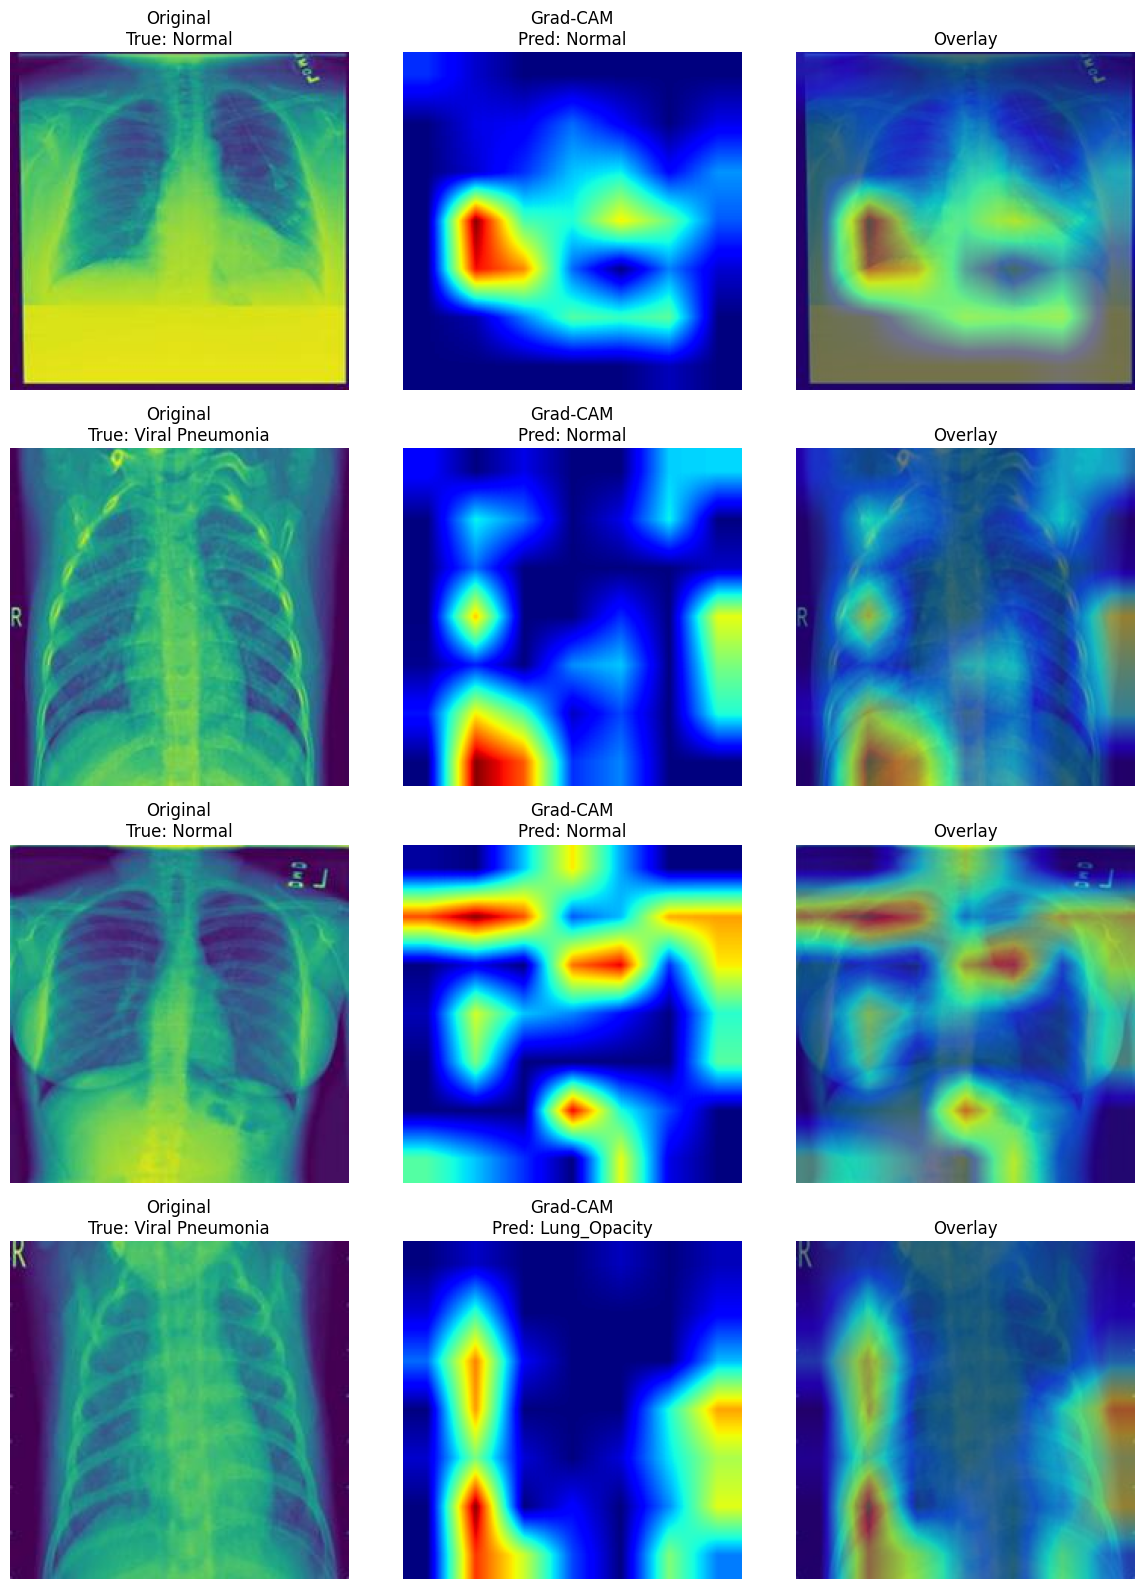

In [30]:
# Grad-CAM visualization for a few test samples (uses existing grad_cam, grad_cam_model, test_paths, class_names, target_size, device)
import matplotlib.pyplot as plt

def overlay_cam_on_image(pil_img, cam, alpha=0.5, colormap="jet"):
    cam_img = Image.fromarray(np.uint8(cam * 255)).resize(pil_img.size, resample=Image.BILINEAR)
    cam_np = np.array(cam_img) / 255.0
    cmap = plt.get_cmap(colormap)
    heatmap = cmap(cam_np)[:, :, :3]
    img_np = np.array(pil_img).astype(np.float32) / 255.0
    overlay = (1 - alpha) * img_np + alpha * heatmap
    overlay = np.clip(overlay, 0, 1)
    return heatmap, overlay

n = 4
fig, axs = plt.subplots(n, 3, figsize=(12, 4 * n))
preproc = transforms.Compose([
    transforms.Resize(target_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

for i in range(n):
    img_path = test_paths[i]
    pil_img = Image.open(img_path).convert("RGB").resize(target_size)
    x = preproc(pil_img).unsqueeze(0).to(device)

    # predict class
    logits = grad_cam_model(x)
    pred_idx = int(torch.softmax(logits, dim=1).argmax(dim=1).item())
    pred_name = class_names[pred_idx]
    true_name = test_labels[i]

    # generate cam (no torch.no_grad here because generate does backward)
    cam = grad_cam.generate(x, class_idx=pred_idx)  # (H, W) numpy, normalized

    heatmap, overlay = overlay_cam_on_image(pil_img, cam, alpha=0.5)

    ax0, ax1, ax2 = axs[i]
    ax0.imshow(pil_img); ax0.set_title(f"Original\nTrue: {true_name}"); ax0.axis("off")
    ax1.imshow(heatmap); ax1.set_title(f"Grad-CAM\nPred: {pred_name}"); ax1.axis("off")
    ax2.imshow(overlay); ax2.set_title("Overlay"); ax2.axis("off")

plt.tight_layout()
plt.show()

In [33]:
# Export the trained model for deployment

# Create export directory
export_dir = Path("model_export")
export_dir.mkdir(exist_ok=True)

# Save the trained model
model_path = export_dir / "hybrid_lstm_classifier.pt"
torch.save(model.state_dict(), model_path)
print(f"Model weights saved to: {model_path}")

# Save model architecture info
architecture_info = {
    "input_size": input_size,
    "hidden_size": 128,
    "dense_size": 128,
    "num_classes": len(class_names),
    "dropout": 0.5,
    "seq_len": seq_len,
    "feature_dim": 2048,
    "class_names": class_names,
    "target_size": target_size
}

config_path = export_dir / "model_config.json"
with open(config_path, "w") as f:
    json.dump(architecture_info, f, indent=2)
print(f"Model configuration saved to: {config_path}")

# Save Grad-CAM model
gradcam_path = export_dir / "gradcam_model.pt"
torch.save(grad_cam_model.state_dict(), gradcam_path)
print(f"Grad-CAM model saved to: {gradcam_path}")

# Create model loading utility
loading_code = '''

def load_hybrid_model(model_dir):
    """Load the trained hybrid LSTM classifier"""
    config_path = Path(model_dir) / "model_config.json"
    model_path = Path(model_dir) / "hybrid_lstm_classifier.pt"
    
    with open(config_path, "r") as f:
        config = json.load(f)
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    model = HybridLSTMClassifier(
        input_size=config["input_size"],
        hidden_size=config["hidden_size"],
        dense_size=config["dense_size"],
        num_classes=config["num_classes"],
        dropout=config["dropout"]
    ).to(device)
    
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    
    return model, config, device
'''

utility_path = export_dir / "model_utils.py"
with open(utility_path, "w") as f:
    f.write(loading_code)
print(f"Model utility functions saved to: {utility_path}")

print("\n" + "="*70)
print("MODEL EXPORT COMPLETE")
print("="*70)
print(f"Export directory: {export_dir}")
print(f"Files created:")
print(f"  - hybrid_lstm_classifier.pt (model weights)")
print(f"  - model_config.json (architecture configuration)")
print(f"  - gradcam_model.pt (Grad-CAM visualization model)")
print(f"  - model_utils.py (loading utilities)")
print("="*70)

Model weights saved to: model_export/hybrid_lstm_classifier.pt
Model configuration saved to: model_export/model_config.json
Grad-CAM model saved to: model_export/gradcam_model.pt
Model utility functions saved to: model_export/model_utils.py

MODEL EXPORT COMPLETE
Export directory: model_export
Files created:
  - hybrid_lstm_classifier.pt (model weights)
  - model_config.json (architecture configuration)
  - gradcam_model.pt (Grad-CAM visualization model)
  - model_utils.py (loading utilities)
